# EVALUACIÓN FINAL: DISEÑO Y ANÁLISIS DE UN EXPERIMENTO SOBRE EL RENDIMIENTO ACADÉMICO

Imagina que trabajas en una institución educativa interesada en evaluar si un nuevo **programa de tutoría** mejora el rendimiento académico de los estudiantes. Para ello se selecciona una muestra de **30 estudiantes**, divididos en dos grupos:

- **Grupo A (15 estudiantes):** Recibe el programa de tutoría.  
- **Grupo B (15 estudiantes):** No recibe el programa (grupo de control).

Los resultados del rendimiento académico se miden mediante un examen estándar (0 a 100 puntos).


In [1]:
# Librerías 
import pandas as pd
import numpy as np
import sklearn 
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import t

def tabla(dfx, fmt='fancy_grid', decimals=2, title=None):
    """
    Muestra un DataFrame o Series en formato tabulado con título opcional.
    
    Parámetros:
    dfx : DataFrame o Series
    fmt : str, formato de tabulate (default: 'fancy_grid')
    decimals : int, número de decimales (default: 2)
    title : str, título de la tabla (default: None)
    """
    # Si es Series → convertir a DataFrame
    if isinstance(dfx, pd.Series):
        dfx = dfx.to_frame(name="Valor")

    # Redondear si son datos numéricos
    try:
        dfx = dfx.round(decimals)
    except:
        pass  # ignora si no aplica

    # Imprimir título si existe
    if title:
        print(f"\n {title}\n" + "-" * (len(title) + 2))

    print(tabulate(dfx, headers="keys", tablefmt=fmt))



In [2]:
# Set de datos 
# Datos
group_a = [85, 90, 78, 88, 92, 80, 86, 89, 84, 87, 91, 82, 83, 85, 88]
group_b = [70, 72, 75, 78, 80, 68, 74, 76, 79, 77, 73, 71, 75, 78, 80]

# Crear DataFrame en formato largo
df = pd.DataFrame({
    "Grupo": ["A"]*len(group_a) + ["B"]*len(group_b),
    "Puntaje": group_a + group_b
})

print(df)

   Grupo  Puntaje
0      A       85
1      A       90
2      A       78
3      A       88
4      A       92
5      A       80
6      A       86
7      A       89
8      A       84
9      A       87
10     A       91
11     A       82
12     A       83
13     A       85
14     A       88
15     B       70
16     B       72
17     B       75
18     B       78
19     B       80
20     B       68
21     B       74
22     B       76
23     B       79
24     B       77
25     B       73
26     B       71
27     B       75
28     B       78
29     B       80


## 1. Diseño del Experimento (1 punto)
- Explica brevemente cómo se podría **mejorar el diseño** del experimento para **reducir posibles sesgos**.

**Respuesta**: para reducir el sesgo se podría:
- Aumentar la muestra o la población.
- Generar división dentro de los mismos grupos


## 2. Cálculo de Estadísticas Descriptivas (3 puntos)
- Calcula la **media** y la **desviación estándar** para ambos grupos.  
- Representa los datos **gráficamente** (histogramas o diagramas de caja).


In [3]:
type(df)

pandas.core.frame.DataFrame

In [4]:
# Media y desviación de cada grupo directamente
grupo_a=df[df["Grupo"] == "A"]["Puntaje"]
media_a = grupo_a.mean()
std_a   = grupo_a.std()


grupo_b=df[df["Grupo"] == "B"]["Puntaje"]
media_b = grupo_b.mean()
std_b   = grupo_b.std()

print(f"Grupo A → Media: {media_a:.2f}, Desviación estándar: {std_a:.2f}")
print(f"Grupo B → Media: {media_b:.2f}, Desviación estándar: {std_b:.2f}")

Grupo A → Media: 85.87, Desviación estándar: 4.02
Grupo B → Media: 75.07, Desviación estándar: 3.71


In [5]:
# Calcular media y desviación estándar por grupo
resumen = df.groupby("Grupo")["Puntaje"].agg(["mean", "std"]).reset_index()
resumen.rename(columns={"mean": "Media", "std": "Desviación estándar"}, inplace=True)

tabla(resumen)

# Obtener la media y desviación estándar del Grupo A
media_a = resumen.loc[resumen["Grupo"] == "A", "Media"].values[0]
std_a   = resumen.loc[resumen["Grupo"] == "A", "Desviación estándar"].values[0]

# Obtener la media y desviación estándar del Grupo B
media_b = resumen.loc[resumen["Grupo"] == "B", "Media"].values[0]
std_b   = resumen.loc[resumen["Grupo"] == "B", "Desviación estándar"].values[0]

print(f'''
La media del grupo A es {media_a:.2f},y su desviacion standard es de {std_a:.2f},
La media del grupo B es {media_b:.2f},y su desviacion standard es de {std_b:.2f}.
Se puede observar que la media del grupo A tiene una diferencia aproximada de 10 unidades,
respecto a la media del grupo B, sin embargo, la desviación estándar del grupo bes 0,3 unidades 
menor aproximadamente. 
también es importante destacar que el mínimo puntaje del grupo A es mayor que. la media de
el grupo B. Se puede inferir quehay una correlación directa entre el programa de tutoría y 
los puntajes de los estudiantes.
      ''')

╒════╤═════════╤═════════╤═══════════════════════╕
│    │ Grupo   │   Media │   Desviación estándar │
╞════╪═════════╪═════════╪═══════════════════════╡
│  0 │ A       │   85.87 │                  4.02 │
├────┼─────────┼─────────┼───────────────────────┤
│  1 │ B       │   75.07 │                  3.71 │
╘════╧═════════╧═════════╧═══════════════════════╛

La media del grupo A es 85.87,y su desviacion standard es de 4.02,
La media del grupo B es 75.07,y su desviacion standard es de 3.71.
Se puede observar que la media del grupo A tiene una diferencia aproximada de 10 unidades,
respecto a la media del grupo B, sin embargo, la desviación estándar del grupo bes 0,3 unidades 
menor aproximadamente. 
también es importante destacar que el mínimo puntaje del grupo A es mayor que. la media de
el grupo B. Se puede inferir quehay una correlación directa entre el programa de tutoría y 
los puntajes de los estudiantes.
      


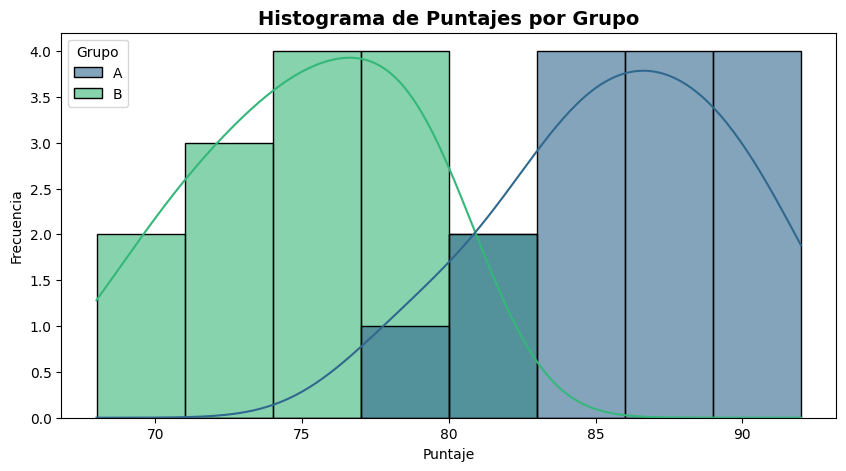

In [6]:
# Gráfico de datos 
# --------- Histograma ----------
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Puntaje", 
             hue="Grupo", 
             kde=True, 
             palette="viridis", 
             bins=8, alpha=0.6)
plt.title("Histograma de Puntajes por Grupo", fontsize=14, fontweight="bold")
plt.xlabel("Puntaje")
plt.ylabel("Frecuencia")
plt.show()


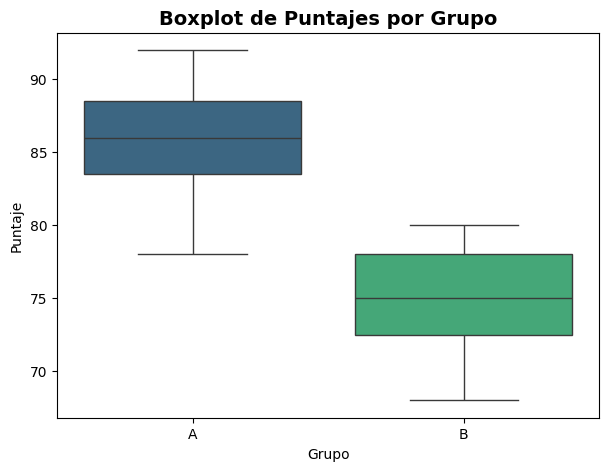

In [7]:
# --------- Boxplot ----------
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Grupo",
            y="Puntaje",   
            hue="Grupo",
            palette="viridis")
plt.title("Boxplot de Puntajes por Grupo", fontsize=14, fontweight="bold")
plt.xlabel("Grupo")
plt.ylabel("Puntaje")
plt.show()

## 3. Prueba de Hipótesis (4 puntos)
- Plantea la **hipótesis nula (H0)** y **alternativa (H1)**:  
  - **H0:** No hay diferencia en el rendimiento académico entre los dos grupos.  
  - **H1:** El grupo con tutoría tiene un mejor rendimiento académico.  
- Realiza una **prueba t** para comparar las medias de ambos grupos. Usa **α = 0.05**.  
- **Interpreta** el valor-p y decide si **rechazas o no** la hipótesis nula.


Hipótesis:
-   H_0: No hay diferencia en el puntaje entre los grupos.
    media grupo A = media grupo B 
-   H_1: Hay diferencia significativa entre ambos grupos.
    media brupo A <> Media grupo B
    


In [8]:
# T-test
# T-test
t_stat, p_value = ttest_ind(grupo_a, grupo_b, equal_var=True)

print(f"Estadístico t = {t_stat:.3f}")
print(f"p-valor = {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print(f"""Se rechaza H0, 
Dado que existe diferencia significativa entre ambos grupos, y según la magnitud de los datos,
se rechaza la hipótesis nula.
          """)
else:
    print(f" No se rechaza H0 (no hay diferencia significativa).")



Estadístico t = 7.649
p-valor = 0.00000
Se rechaza H0, 
Dado que existe diferencia significativa entre ambos grupos, y según la magnitud de los datos,
se rechaza la hipótesis nula.
          


## 4. Intervalo de Confianza (2 puntos)
- Calcula un **intervalo de confianza del 95%** para la **diferencia de medias** entre los dos grupos.  
- **Interpreta** el resultado.


In [9]:
# Parámetros de la prueba
mu_0=media_b     # Hipótesis nula
mu_1 = media_a      # Hipótesis alternativa 
s = 1.28        # Desviación estándar muestral (estimador de sigma)
n = len(df)          # Tamaño muestral
alpha = 0.05    # Nivel de significancia

# Grados de libertad
fd = n - 1
# Paso 1: Calcular valores críticos para prueba bilateral con t
t_crit = t.ppf(1 - alpha / 2, fd)
x_crit_izq = mu_0 - t_crit * (s / np.sqrt(n))
x_crit_der = mu_0 + t_crit * (s / np.sqrt(n))
print(f"Valores críticos (bajo H0): {x_crit_izq:.2f}, {x_crit_der:.2f}")
print(F"""
El valor de la media del grupo control es de {media_b:.2f}, dado esto, los valores críticos del test-t
con una confianza del 95%, son {x_crit_izq:.2f},{x_crit_der:.2f}, mientras que el valor de la media del grupo que
tuvo tutorías es de {media_a:.2f}, por lo tanto, hay sufucientes datos para rechazar la hipótesis nula
""")
# Paso 2: Calcular β (error tipo II) y potencia
# Bajo H1, usamos mu_1 como media verdadera
t_beta_izq = (x_crit_izq - mu_1) / (s / np.sqrt(n))
t_beta_der = (x_crit_der - mu_1) / (s / np.sqrt(n))

beta = t.cdf(t_beta_der, fd) - t.cdf(t_beta_izq, fd)
potencia = 1 - beta
print(f"Error Tipo II (β): {beta:.4f}")
print(f"Potencia de la prueba (1 - β): {potencia:.4f}")

Valores críticos (bajo H0): 74.59, 75.54

El valor de la media del grupo control es de 75.07, dado esto, los valores críticos del test-t
con una confianza del 95%, son 74.59,75.54, mientras que el valor de la media del grupo que
tuvo tutorías es de 85.87, por lo tanto, hay sufucientes datos para rechazar la hipótesis nula

Error Tipo II (β): 0.0000
Potencia de la prueba (1 - β): 1.0000


## INSTRUCCIONES ADICIONALES
- **Puntos totales = 10**.  
- Comprime el archivo completo en formato `.zip` o `.rar`.  
- Sube el archivo a la plataforma.
